# Neural network regression on concrete strength data

In a previous notebook, we used **multivariate linear regression** to predict the compressive strength of concrete from its mix design.

In this notebook, we will solve the same regression problem using a simple neural network implemented with **PyTorch**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

### Utility function: parity plot

In [2]:
def parity_plot(y_true, y_pred, title="Parity Plot"):
    plt.figure()
    
    # Scatter plot: true vs predicted
    #plt.scatter(y_true, y_pred, s=80, c='k', marker='x', linewidth=0.7, zorder=1)

    # For large datasets, individual scatter points may overlap, making it difficult to assess the distribution of predictions. 
    # Hexagonal binning addresses this issue by grouping points into bins and visualizing their frequency through color intensity. 
    # The associated colorbar indicates the number of samples within each bin.
    hb = plt.hexbin(y_true, y_pred, zorder=-1, cmap='gray_r', mincnt=1, gridsize=12, edgecolors='none')
    cb = plt.colorbar(hb)
    cb.set_label("Counts per bin")
    
    # Ideal line (perfect prediction)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'goldenrod', linewidth=1.5, zorder=1, linestyle='--')

    plt.xlim([min_val, max_val])
    plt.ylim([min_val, max_val])
    plt.xlabel("True strength [MPa]")
    plt.ylabel("Predicted strength [MPa]")
    plt.title(title)

    # Mean squarred error
    mse = np.mean((y_true - y_pred)**2)
    # R^2 score (coefficient of determination)
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    
    plt.text(min_val, max_val, f"MSE = {mse:.3f}\nR² = {r2:.3f}",
             verticalalignment='top')
    
    plt.show()

### Load data

The dataset contains:

- Input variables describing the concrete composition
- One target variable corresponding to the concrete compressive strength

In [3]:
# Load data from Excel
file_path = "../Data/Concrete/Concrete.xls"
df = pd.read_excel(file_path)

# Display first rows
df.head()

# The dataset is stored in Excel format (.xls).
# Pandas requires the 'xlrd' package to read this format.
# If you get an error, install it via: pip install xlrd.

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


### Define inputs and outputs

In [4]:
# In this dataset, the last column is the concrete compressive strength target
X = df.iloc[1:, :-1].values # all columns except last → input features
y = df.iloc[1:, -1].values.reshape(-1, 1) # last column → target

N, d = X.shape

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print(f"Number of samples: {N}")
print(f"Number of input features: {d}")

Input shape: (1029, 8)
Target shape: (1029, 1)
Number of samples: 1029
Number of input features: 8


### Data normalization

Neural networks are very sensitive to the scale of the input variables. Without normalization:

- Optimization becomes unstable
- Gradients can become too large or too small
- Training becomes less effective

We standardize the features to display zero mean and unit variance.


---

### Split and normalize the data

- Split using 80% train and 20% test
- Compute normalization statistics from training data
- Consistently apply normalization to the test data


In [5]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Convert NumPy arrays to PyTorch tensors

In [6]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

### Define the neural network

We use a small feed-forward neural network:

- Input layer
- One hidden layer with ReLU activation
- One output neuron for regression

Mathematically:

$\hat{y} = \mathbf{W}_2 \cdot \sigma(\mathbf{W}_1 \cdot \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2$

where:

- $\sigma$ is the ReLU activation function
- $\mathbf{W}$ and $\mathbf{b}$ are trainable parameters

In [7]:
class ConcreteNN(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [8]:
input_size = X_train_tensor.shape[1]

model = ConcreteNN(input_size)

print(model)

ConcreteNN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)


### Training loop with mini-batch optimization

We minimize the **Mean Squared Error (MSE)** loss function
    
$MSE = \frac{1}{N} \sum_i (y_i - \hat{y}_i)^2$,

using the **Adam optimizer**

In [9]:
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader, t_u_val, t_c_val):

    loss_history = []
    
    for epoch in range(1, n_epochs + 1):

        epoch_loss = 0.0

        # Mini-batch loop
        for t_u_batch, t_c_batch in train_loader:
            t_p_train = model(t_u_batch) 
            loss_train = loss_fn(t_p_train, t_c_batch)
    
            optimizer.zero_grad()
            loss_train.backward()
            optimizer.step()
            epoch_loss += loss_train.item()
    
        # Average training loss over batches
        epoch_loss /= len(train_loader)
            
        t_p_val = model(t_u_val) 
        loss_val = loss_fn(t_p_val, t_c_val)
        
        loss_history.append([epoch_loss,loss_val.item()])

        if epoch == 1 or epoch % 500 == 0:
            print(f"Epoch {epoch}, Training loss {epoch_loss:.4f},"
                  f" Validation loss {loss_val.item():.4f}")

    return np.asarray(loss_history)

n_samples = X_train_tensor.shape[0]
n_val = int(0.2 * n_samples)
shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
t_un_train = X_train_tensor[train_indices]
t_c_train = y_train_tensor[train_indices]
t_un_val = X_train_tensor[val_indices]
t_c_val = y_train_tensor[val_indices]

# mini-batch training
train_dataset = TensorDataset(t_un_train, t_c_train)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True)

loss_history = training_loop(n_epochs = 20000, 
                            optimizer = optim.Adam(model.parameters(), lr=0.001),
                            model = model,
                            loss_fn = nn.MSELoss(),
                            train_loader = train_loader, # mini-batch training
                            t_u_val = t_un_val, 
                            t_c_val = t_c_val)

Epoch 1, Training loss 1560.3570, Validation loss 1578.8496
Epoch 500, Training loss 43.9089, Validation loss 49.9331
Epoch 1000, Training loss 39.9648, Validation loss 43.4128
Epoch 1500, Training loss 39.4143, Validation loss 42.9310
Epoch 2000, Training loss 38.0801, Validation loss 43.6936
Epoch 2500, Training loss 37.7539, Validation loss 42.5908
Epoch 3000, Training loss 36.7722, Validation loss 42.3534
Epoch 3500, Training loss 36.4694, Validation loss 42.9314
Epoch 4000, Training loss 36.5112, Validation loss 42.6724
Epoch 4500, Training loss 36.0316, Validation loss 42.7679
Epoch 5000, Training loss 35.7110, Validation loss 42.7386
Epoch 5500, Training loss 38.4926, Validation loss 42.4200
Epoch 6000, Training loss 35.5224, Validation loss 42.6168
Epoch 6500, Training loss 35.9073, Validation loss 42.5174
Epoch 7000, Training loss 35.7854, Validation loss 42.3117
Epoch 7500, Training loss 36.0368, Validation loss 42.8055
Epoch 8000, Training loss 36.3543, Validation loss 42.57

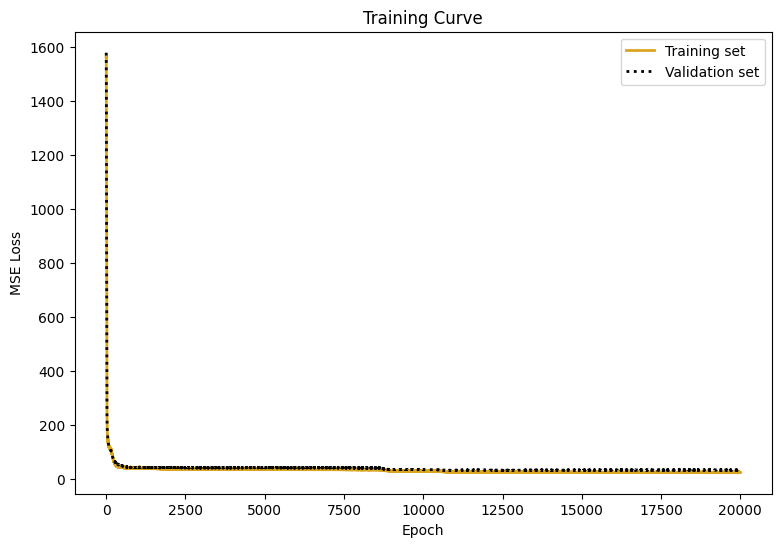

In [10]:
plt.figure(figsize = (9,6))
plt.plot(loss_history[:,0], 'goldenrod', linewidth=2)
plt.plot(loss_history[:,1], 'k:', linewidth=2)    
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend(['Training set', 'Validation set'], loc='upper right')
plt.show()

### Prediction with the neural network

In [11]:
model.eval()

with torch.no_grad():
    y_test_pred = model(X_test_tensor)

# Convert predictions back to NumPy
y_test_pred_np = y_test_pred.numpy()

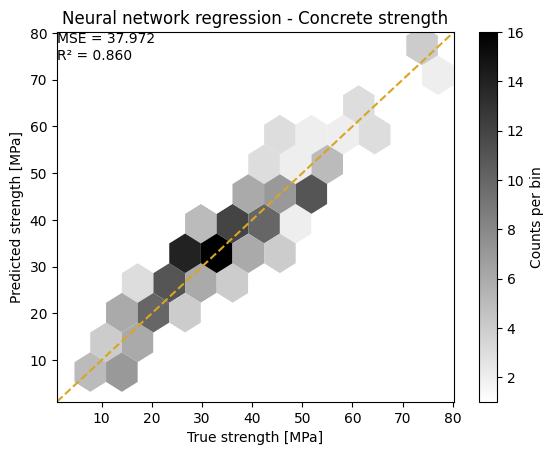

In [12]:
parity_plot(
    y_test.flatten(),
    y_test_pred_np.flatten(),
    title="Neural network regression - Concrete strength"
)

### Predictive performance is measured through:

- Mean Squared Error (MSE)
- Coefficient of determination $R^2$

---

## Remarks: Linear regression vs neural network

### Linear regression

A multivariate linear regression assumes a linear relationship between the inputs and the output:

$y = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$

---

### Neural network

A neural network introduces hidden layers and nonlinear activation functions, allowing to learn:

- nonlinear relationships
- interactions between variables
- more complex patterns in the data

---

### Important observations:

1. Neural networks generally train much better when inputs are standardized.
2. By increasing the number of parameters, a neural network can represent more complex functions than linear regression. However, too many parameters may cause overfitting and require more data for effective training.
3. Neural networks are universal function approximators; even a small network with one hidden layer can approximate highly nonlinear functions.

---

### Exercises

Try a deeper and larger network, for instance:

            self.network = nn.Sequential(
                nn.Linear(input_size, 32),
                nn.ReLU(),
                nn.Linear(32, 16),
                nn.ReLU(),
                nn.Linear(16, 1)
            )

and compare the results.

---

**Remove mini-batch training** and compare the results.

---

Other possible options: 
1. Try different activation functions (sigmoid, Tanh, LeakyReLU...)
2. Compare performance with linear regression
3. Explore the effect of learning rate, number of epochs, ...
4. Add weigth regularization